In [12]:
import pandas as pd
import numpy as np
from pathlib import Path

print("Reading TSLA liquidity zone Excel files...")
print("=" * 70)

Reading TSLA liquidity zone Excel files...


In [13]:
# ---------------------------------------------------------------------------
# Read Daily Results
# ---------------------------------------------------------------------------
print("\n1. Reading DAILY liquidity zone results...")

daily_excel = "TSLA_results_daily.xlsx"

# Read baseline (no MIDAS)
zones_daily_no_midas = pd.read_excel(daily_excel, sheet_name="Liquidity_Zones")
print(f"   ✓ Daily zones (no MIDAS): {len(zones_daily_no_midas)} rows")
print(f"     Columns: {zones_daily_no_midas.columns.tolist()[:5]}...")

# Read MIDAS-enriched (with MIDAS) — for daily, the enriched sheet is named "MIDAS_Zones"
zones_daily_with_midas = pd.read_excel(daily_excel, sheet_name="MIDAS_Zones")
print(f"   ✓ Daily zones (with MIDAS): {len(zones_daily_with_midas)} rows")
print(f"     Columns: {zones_daily_with_midas.columns.tolist()[:5]}...")

# ---------------------------------------------------------------------------
# Read Hourly Results
# ---------------------------------------------------------------------------
print("\n2. Reading HOURLY liquidity zone results...")

hourly_excel = "TSLA_results_hourly.xlsx"

# Read baseline (no MIDAS)
zones_hourly_no_midas = pd.read_excel(hourly_excel, sheet_name="Liquidity_Zones")
print(f"   ✓ Hourly zones (no MIDAS): {len(zones_hourly_no_midas)} rows")
print(f"     Columns: {zones_hourly_no_midas.columns.tolist()[:5]}...")

# Read MIDAS-enriched (with MIDAS) — for hourly, the enriched sheet is named "MIDAS_enriched_Zones"
zones_hourly_with_midas = pd.read_excel(hourly_excel, sheet_name="MIDAS_enriched_Zones")
print(f"   ✓ Hourly zones (with MIDAS): {len(zones_hourly_with_midas)} rows")
print(f"     Columns: {zones_hourly_with_midas.columns.tolist()[:5]}...")

print("\n" + "=" * 70)
print("SUMMARY: 4 dataframes loaded and ready for analysis")
print("=" * 70)
print(f"\n• zones_daily_with_midas:    {len(zones_daily_with_midas):4d} zones (daily, Layer 1+2+3)")
print(f"• zones_daily_no_midas:      {len(zones_daily_no_midas):4d} zones (daily, Layer 1+2)")
print(f"• zones_hourly_with_midas:   {len(zones_hourly_with_midas):4d} zones (hourly, Layer 1+2+3)")
print(f"• zones_hourly_no_midas:     {len(zones_hourly_no_midas):4d} zones (hourly, Layer 1+2)")


1. Reading DAILY liquidity zone results...
   ✓ Daily zones (no MIDAS): 19 rows
     Columns: ['zone_id', 'top', 'bottom', 'height', 'touches']...
   ✓ Daily zones (with MIDAS): 19 rows
     Columns: ['zone_id', 'cancel_to_trade_avg', 'hidden_rate_avg', 'hidden_volume_avg', 'fill_rate_avg']...

2. Reading HOURLY liquidity zone results...
   ✓ Hourly zones (no MIDAS): 177 rows
     Columns: ['zone_id', 'top', 'bottom', 'height', 'touches']...
   ✓ Hourly zones (with MIDAS): 89 rows
     Columns: ['zone_id', 'top', 'bottom', 'touches', 'strength']...

SUMMARY: 4 dataframes loaded and ready for analysis

• zones_daily_with_midas:      19 zones (daily, Layer 1+2+3)
• zones_daily_no_midas:        19 zones (daily, Layer 1+2)
• zones_hourly_with_midas:     89 zones (hourly, Layer 1+2+3)
• zones_hourly_no_midas:      177 zones (hourly, Layer 1+2)


In [14]:
# ---------------------------------------------------------------------------
# Feature Column Inventory (MIDAS vs No-MIDAS)
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("MIDAS-SPECIFIC COLUMNS")
print("=" * 70)

midas_cols = [
    "cancel_to_trade_avg",
    "hidden_rate_avg",
    "hidden_volume_avg",
    "fill_rate_avg",
    "oddlot_rate_avg",
    "oddlot_volume_avg",
]

print("\nMIDAS columns present in WITH_MIDAS sets:")
daily_midas_present = [c for c in midas_cols if c in zones_daily_with_midas.columns]
hourly_midas_present = [c for c in midas_cols if c in zones_hourly_with_midas.columns]

print(f"  Daily: {daily_midas_present}")
print(f"  Hourly: {hourly_midas_present}")

print("\nMIDAS columns present in NO_MIDAS sets:")
daily_midas_absent = [c for c in midas_cols if c in zones_daily_no_midas.columns]
hourly_midas_absent = [c for c in midas_cols if c in zones_hourly_no_midas.columns]

print(f"  Daily: {daily_midas_absent if daily_midas_absent else '(none)'}")
print(f"  Hourly: {hourly_midas_absent if hourly_midas_absent else '(none)'}")

print("\n✓ Data successfully loaded and separated into 4 model-training datasets!")


MIDAS-SPECIFIC COLUMNS

MIDAS columns present in WITH_MIDAS sets:
  Daily: ['cancel_to_trade_avg', 'hidden_rate_avg', 'hidden_volume_avg', 'fill_rate_avg', 'oddlot_rate_avg', 'oddlot_volume_avg']
  Hourly: ['cancel_to_trade_avg', 'hidden_rate_avg', 'hidden_volume_avg', 'fill_rate_avg', 'oddlot_rate_avg', 'oddlot_volume_avg']

MIDAS columns present in NO_MIDAS sets:
  Daily: ['cancel_to_trade_avg', 'hidden_rate_avg', 'hidden_volume_avg', 'fill_rate_avg', 'oddlot_rate_avg', 'oddlot_volume_avg']
  Hourly: ['cancel_to_trade_avg', 'hidden_rate_avg', 'hidden_volume_avg', 'fill_rate_avg', 'oddlot_rate_avg', 'oddlot_volume_avg']

✓ Data successfully loaded and separated into 4 model-training datasets!


In [15]:
print("\nHourly Zones WITH MIDAS (Layer 1+2+3):")
print(f"  Shape: {zones_hourly_with_midas.shape}")
print(f"  Columns: {list(zones_hourly_with_midas.columns)}")
display(zones_hourly_with_midas.head(3))

print("\n" + "-" * 70)
print("\nHourly Zones WITHOUT MIDAS (Layer 1+2):")
print(f"  Shape: {zones_hourly_no_midas.shape}")
print(f"  Columns: {list(zones_hourly_no_midas.columns)}")
display(zones_hourly_no_midas.head(3))


Hourly Zones WITH MIDAS (Layer 1+2+3):
  Shape: (89, 14)
  Columns: ['zone_id', 'top', 'bottom', 'touches', 'strength', 'avg_absorption', 'dist_to_poc', 'poc_volume_ratio', 'cancel_to_trade_avg', 'hidden_rate_avg', 'hidden_volume_avg', 'fill_rate_avg', 'oddlot_rate_avg', 'oddlot_volume_avg']


,zone_id,top,bottom,touches,strength,avg_absorption,dist_to_poc,poc_volume_ratio,cancel_to_trade_avg,hidden_rate_avg,hidden_volume_avg,fill_rate_avg,oddlot_rate_avg,oddlot_volume_avg
0,2021-01-15_to_2021-01-19,286.63,283.01,2,0.026526,7.474472,55.57,1.159127,10.387258,34.237010,32.916641,6.397417,90.108373,48.314849
1,2021-01-25_to_2021-01-26,300.13,298.63,2,0.026739,2.645406,70.13,0.838072,10.288741,35.791916,32.244626,6.586118,89.828516,48.324117
2,2021-01-08_to_2021-02-08,294.83,292.53,2,0.026998,8.669269,64.43,1.225861,10.275632,36.948114,33.176085,6.351552,90.316534,50.043585



----------------------------------------------------------------------

Hourly Zones WITHOUT MIDAS (Layer 1+2):
  Shape: (177, 22)
  Columns: ['zone_id', 'top', 'bottom', 'height', 'touches', 'first_idx', 'last_idx', 'first_time', 'last_time', 'total_volume', 'avg_volume', 'volume_node_score', 'strength', 'avg_absorption', 'dist_to_poc', 'poc_volume_ratio', 'cancel_to_trade_avg', 'hidden_rate_avg', 'hidden_volume_avg', 'fill_rate_avg', 'oddlot_rate_avg', 'oddlot_volume_avg']


,zone_id,top,bottom,height,touches,first_idx,last_idx,first_time,last_time,total_volume,...,strength,avg_absorption,dist_to_poc,poc_volume_ratio,cancel_to_trade_avg,hidden_rate_avg,hidden_volume_avg,fill_rate_avg,oddlot_rate_avg,oddlot_volume_avg
0,2021-01-15_to_2021-01-19,286.63,283.01,3.62,2,63,70,2021-01-15 09:30:00,2021-01-19 09:30:00,59706273.0,...,0.026526,7.474472,55.57,1.159127,10.387258,34.237010,32.916641,6.397417,90.108373,48.314849
1,2021-01-25_to_2021-01-26,300.13,298.63,1.50,2,98,105,2021-01-25 09:30:00,2021-01-26 09:30:00,62767161.0,...,0.026739,2.645406,70.13,0.838072,10.288741,35.791916,32.244626,6.586118,89.828516,48.324117
2,2021-01-08_to_2021-02-08,294.83,292.53,2.30,2,29,168,2021-01-08 10:30:00,2021-02-08 09:30:00,62669307.0,...,0.026998,8.669269,64.43,1.225861,10.275632,36.948114,33.176085,6.351552,90.316534,50.043585


In [16]:
# ---------------------------------------------------------------------------
# Display Schema & Comparison
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("SCHEMA COMPARISON")
print("=" * 70)

print("\nDaily Zones WITH MIDAS (Layer 1+2+3):")
print(f"  Shape: {zones_daily_with_midas.shape}")
print(f"  Columns: {list(zones_daily_with_midas.columns)}")
display(zones_daily_with_midas.head(3))

print("\n" + "-" * 70)
print("\nDaily Zones WITHOUT MIDAS (Layer 1+2):")
print(f"  Shape: {zones_daily_no_midas.shape}")
print(f"  Columns: {list(zones_daily_no_midas.columns)}")
display(zones_daily_no_midas.head(3))


SCHEMA COMPARISON

Daily Zones WITH MIDAS (Layer 1+2+3):
  Shape: (19, 7)
  Columns: ['zone_id', 'cancel_to_trade_avg', 'hidden_rate_avg', 'hidden_volume_avg', 'fill_rate_avg', 'oddlot_rate_avg', 'oddlot_volume_avg']


,zone_id,cancel_to_trade_avg,hidden_rate_avg,hidden_volume_avg,fill_rate_avg,oddlot_rate_avg,oddlot_volume_avg
0,2021-04-14_to_2021-04-22,21.246701,37.504190,30.220429,2.251482,90.648456,52.259063
1,2021-03-05_to_2021-05-19,19.324770,38.154084,29.898420,2.619293,90.911179,52.270896
2,2021-03-10_to_2021-07-02,19.689641,38.330254,28.124481,2.560650,90.284579,50.690828



----------------------------------------------------------------------

Daily Zones WITHOUT MIDAS (Layer 1+2):
  Shape: (19, 22)
  Columns: ['zone_id', 'top', 'bottom', 'height', 'touches', 'first_idx', 'last_idx', 'first_time', 'last_time', 'total_volume', 'avg_volume', 'volume_node_score', 'strength', 'avg_absorption', 'dist_to_poc', 'poc_volume_ratio', 'cancel_to_trade_avg', 'hidden_rate_avg', 'hidden_volume_avg', 'fill_rate_avg', 'oddlot_rate_avg', 'oddlot_volume_avg']


,zone_id,top,bottom,height,touches,first_idx,last_idx,first_time,last_time,total_volume,...,strength,avg_absorption,dist_to_poc,poc_volume_ratio,cancel_to_trade_avg,hidden_rate_avg,hidden_volume_avg,fill_rate_avg,oddlot_rate_avg,oddlot_volume_avg
0,2021-04-14_to_2021-04-22,260.263336,251.256668,9.006668,2,69,75,2021-04-14,2021-04-22,253823100,...,0.030791,1.431716,48.260002,1.126446,21.246701,37.504190,30.220429,2.251482,90.648456,52.259063
1,2021-03-05_to_2021-05-19,182.326660,179.830002,2.496658,2,42,94,2021-03-05,2021-05-19,386924700,...,0.032152,4.292788,26.421669,0.706196,19.324770,38.154084,29.898420,2.619293,90.911179,52.270896
2,2021-03-10_to_2021-07-02,239.283340,232.539993,6.743347,4,45,125,2021-03-10,2021-07-02,526456200,...,0.067729,14.077108,28.411667,1.368882,19.689641,38.330254,28.124481,2.560650,90.284579,50.690828


# TSLA Liquidity Zone Analysis: With/Without MIDAS Comparison

This notebook reads the pre-computed liquidity zone results and separates them into 4 datasets:

1. **Daily zones WITH MIDAS** — Layer 1+2+3 institutional enrichment
2. **Daily zones WITHOUT MIDAS** — Layer 1+2 baseline (volume + absorption only)
3. **Hourly zones WITH MIDAS** — Layer 1+2+3 institutional enrichment
4. **Hourly zones WITHOUT MIDAS** — Layer 1+2 baseline (volume + absorption only)

Each dataset is then used for independent model training on volume vs order-flow variants.

In [17]:
# ---------------------------------------------------------------------------
# LOAD HOURLY PRICE DATA FOR SWEEP ANALYSIS
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("LOADING HOURLY PRICE DATA")
print("=" * 70)

# Load hourly OHLCV data
hourly_data = pd.read_csv("data/raw/TSLA_hourly_2021-01-04_2024-09-30.csv")
# Rename columns to lowercase for consistency
hourly_data.columns = hourly_data.columns.str.lower()
hourly_data = hourly_data.rename(columns={'datetime': 'timestamp', '% change': 'pct_change'})
hourly_data['timestamp'] = pd.to_datetime(hourly_data['timestamp'])
hourly_data = hourly_data.sort_values('timestamp').reset_index(drop=True)

print(f"✓ Loaded {len(hourly_data)} hourly candles")
print(f"  Date range: {hourly_data['timestamp'].min()} to {hourly_data['timestamp'].max()}")
print(f"  Columns: {list(hourly_data.columns)}")

# Compute candle metrics
hourly_data['body'] = abs(hourly_data['close'] - hourly_data['open'])
hourly_data['high_wick'] = hourly_data['high'] - hourly_data[['open', 'close']].max(axis=1)
hourly_data['low_wick'] = hourly_data[['open', 'close']].min(axis=1) - hourly_data['low']
hourly_data['total_range'] = hourly_data['high'] - hourly_data['low']
hourly_data['wick_ratio'] = hourly_data['total_range'] / (hourly_data['body'] + 0.0001)  # Avoid division by zero
hourly_data['direction'] = np.where(hourly_data['close'] > hourly_data['open'], 1, 
                                     np.where(hourly_data['close'] < hourly_data['open'], -1, 0))

# Calculate returns and price changes
hourly_data['returns'] = hourly_data['close'].pct_change()
hourly_data['price_move'] = hourly_data['close'] - hourly_data['open']
hourly_data['high_low_range'] = hourly_data['high'] - hourly_data['low']

# Volume analysis
hourly_data['volume_zscore'] = (hourly_data['volume'] - hourly_data['volume'].rolling(20).mean()) / (hourly_data['volume'].rolling(20).std() + 0.0001)
hourly_data['volume_spike'] = hourly_data['volume_zscore'] > 2  # Volume spike threshold

print("\n✓ Candle metrics computed")
print(f"  Sample body sizes: {hourly_data['body'].describe()}")
print(f"  Sample wick ratios: {hourly_data['wick_ratio'].describe()}")



LOADING HOURLY PRICE DATA
✓ Loaded 6577 hourly candles
  Date range: 2021-01-04 09:30:00 to 2024-09-30 15:30:00
  Columns: ['timestamp', 'open', 'high', 'low', 'close', 'pct_change', 'volume']

✓ Candle metrics computed
  Sample body sizes: count    6577.000000
mean        1.810751
std         2.040291
min         0.000000
25%         0.510000
50%         1.180000
75%         2.380000
max        27.110000
Name: body, dtype: float64
  Sample wick ratios: count     6577.000000
mean        54.122898
std        976.711686
min          1.001797
25%          1.507694
50%          2.185538
75%          4.210845
max      36400.000000
Name: wick_ratio, dtype: float64


In [18]:
# ---------------------------------------------------------------------------
# SWEEP DETECTION FUNCTIONS
# ---------------------------------------------------------------------------

def detect_market_structure_shift(prices, window=5):
    """
    Detect Market Structure Shift (MSS) - highs/lows changes
    Returns: 1 for bullish MSS, -1 for bearish MSS, 0 for no shift
    """
    if len(prices) < window * 2:
        return 0
    
    recent_highs = prices[-window:].max()
    recent_lows = prices[-window:].min()
    prior_highs = prices[-window*2:-window].max()
    prior_lows = prices[-window*2:-window].min()
    
    # Bullish MSS: higher lows
    if recent_lows > prior_lows and recent_highs >= prior_highs:
        return 1
    # Bearish MSS: lower highs
    elif recent_highs < prior_highs and recent_lows <= prior_lows:
        return -1
    
    return 0

def detect_change_of_character(closes, window=8):
    """
    Detect Change of Character (CHoCH) - shift in momentum
    Returns: 1 for bullish, -1 for bearish, 0 for none
    """
    if len(closes) < window * 2:
        return 0
    
    recent_momentum = closes[-window:].mean() - closes[-window*2:-window].mean()
    prior_momentum = closes[-window*2:-window].mean() - closes[-window*3:-window*2].mean() if len(closes) > window * 3 else 0
    
    if recent_momentum > 0 and prior_momentum <= 0:
        return 1  # Bullish CHoCH
    elif recent_momentum < 0 and prior_momentum >= 0:
        return -1  # Bearish CHoCH
    
    return 0

def detect_double_bottom_bust(lows, window=5):
    """
    Detect busted double bottoms - pattern that breaks one way then reverses
    Looks for two similar lows followed by break and reversal
    """
    if len(lows) < window * 3:
        return False
    
    low1 = lows[-window*2:-window].min()
    low2 = lows[-window:].min()
    recent_low = lows[-1]
    
    # Similar lows (within 1% tolerance)
    if abs(low1 - low2) / low1 < 0.01:
        # Pattern breaks lower then reverses up
        if recent_low < low1 * 0.99 and lows[-1] > lows[-2]:
            return True
    
    return False

def detect_double_top_bust(highs, window=5):
    """
    Detect busted double tops - pattern that breaks one way then reverses
    Looks for two similar highs followed by break and reversal
    """
    if len(highs) < window * 3:
        return False
    
    high1 = highs[-window*2:-window].max()
    high2 = highs[-window:].max()
    recent_high = highs[-1]
    
    # Similar highs (within 1% tolerance)
    if abs(high1 - high2) / high1 < 0.01:
        # Pattern breaks higher then reverses down
        if recent_high > high1 * 1.01 and highs[-1] < highs[-2]:
            return True
    
    return False

def score_sweep_quality(row, data_window=20):
    """
    Calculate sweep quality score based on multiple characteristics
    Higher score = higher quality sweep
    """
    score = 0
    max_score = 100
    
    # 1. Wick-to-Body Ratio (0-20 points)
    # High ratio indicates rejection
    if row['wick_ratio'] > 2:
        score += 20
    elif row['wick_ratio'] > 1:
        score += 10
    elif row['wick_ratio'] > 0.5:
        score += 5
    
    # 2. Candle Size (0-15 points)
    # Large candles indicate bold moves
    if row['total_range'] > 0:
        score += min(15, row['total_range'] * 50)  # Scale factor
    
    # 3. Volume Spike (0-20 points)
    if row['volume_spike']:
        score += 20
    elif row['volume_zscore'] > 1.5:
        score += 10
    elif row['volume_zscore'] > 1:
        score += 5
    
    # 4. Body Size (boldness) (0-15 points)
    # Large body = bold move
    if row['body'] > 0:
        score += min(15, row['body'] * 50)  # Scale factor
    
    # 5. Directional Strength (0-10 points)
    if row['direction'] != 0:
        score += 10
    
    # 6. Long Wick Indicator (0-15 points)
    max_wick = max(row['high_wick'], row['low_wick'])
    if max_wick / row['total_range'] > 0.5 if row['total_range'] > 0 else False:
        score += 15
    elif max_wick / row['total_range'] > 0.3 if row['total_range'] > 0 else False:
        score += 7
    
    return min(score, max_score)

def identify_sweeps_in_zones(zones_df, price_data, midas_mode=False):
    """
    Identify sweeps within each liquidity zone
    """
    sweeps = []
    
    for idx, zone in zones_df.iterrows():
        # Handle different column names from different sheets
        # Try to get zone entry time from first_time, or parse from zone_id
        if 'first_time' in zone.index:
            zone_entry = pd.to_datetime(zone['first_time'])
        elif 'zone_id' in zone.index:
            # Parse date from zone_id like '2021-01-15_to_2021-01-19'
            # Use the START date with market open time (09:30)
            zone_id_start = str(zone['zone_id']).split('_to_')[0]
            zone_entry = pd.to_datetime(f"{zone_id_start} 09:30:00")
        else:
            continue  # Skip if no timestamp info available
        
        zone_high = zone['top']
        zone_low = zone['bottom']
        zone_mid = (zone_high + zone_low) / 2
        
        # Get price data around zone (before and after)
        # Extend search window for multi-day MIDAS zones
        search_window_before = pd.Timedelta(hours=20) if midas_mode else pd.Timedelta(hours=5)
        search_window_after = pd.Timedelta(hours=20) if midas_mode else pd.Timedelta(hours=10)
        
        zone_mask = (price_data['timestamp'] >= zone_entry - search_window_before) & \
                    (price_data['timestamp'] <= zone_entry + search_window_after)
        zone_candles = price_data[zone_mask].copy()
        
        if len(zone_candles) < 3:
            continue
        
        # Find sweep: rapid move into zone + reversal
        for i in range(2, len(zone_candles)):
            # Check if price touched the zone
            current_low = zone_candles.iloc[i]['low']
            current_high = zone_candles.iloc[i]['high']
            prev_close = zone_candles.iloc[i-1]['close']
            
            # Bullish sweep: price drops into zone then reverses up
            if current_low <= zone_low * 1.001 and zone_candles.iloc[i]['close'] > prev_close:
                reversal_dist = zone_candles.iloc[i]['close'] - current_low
                if reversal_dist > 0:
                    sweep_quality = score_sweep_quality(zone_candles.iloc[i])
                    mss = detect_market_structure_shift(zone_candles['close'].values[:i+1])
                    choch = detect_change_of_character(zone_candles['close'].values[:i+1])
                    double_bottom = detect_double_bottom_bust(zone_candles['low'].values[:i+1])
                    
                    sweeps.append({
                        'sweep_idx': len(sweeps),
                        'zone_idx': idx,
                        'timestamp': zone_candles.iloc[i]['timestamp'],
                        'sweep_type': 'BULLISH',
                        'zone_level': zone_low,
                        'sweep_low': current_low,
                        'reversal_price': zone_candles.iloc[i]['close'],
                        'reversal_distance': reversal_dist,
                        'candle_body': zone_candles.iloc[i]['body'],
                        'candle_total_range': zone_candles.iloc[i]['total_range'],
                        'wick_ratio': zone_candles.iloc[i]['wick_ratio'],
                        'volume': zone_candles.iloc[i]['volume'],
                        'volume_spike': zone_candles.iloc[i]['volume_spike'],
                        'volume_zscore': zone_candles.iloc[i]['volume_zscore'],
                        'sweep_quality_score': sweep_quality,
                        'market_structure_shift': mss,
                        'change_of_character': choch,
                        'double_bottom_bust': double_bottom,
                        'midas_filtered': midas_mode,
                        **{k: zone[k] for k in zone.index if k.startswith('absorption') or k.startswith('volume')}
                    })
            
            # Bearish sweep: price rises into zone then reverses down
            if current_high >= zone_high * 0.999 and zone_candles.iloc[i]['close'] < prev_close:
                reversal_dist = current_high - zone_candles.iloc[i]['close']
                if reversal_dist > 0:
                    sweep_quality = score_sweep_quality(zone_candles.iloc[i])
                    mss = detect_market_structure_shift(zone_candles['close'].values[:i+1])
                    choch = detect_change_of_character(zone_candles['close'].values[:i+1])
                    double_top = detect_double_top_bust(zone_candles['high'].values[:i+1])
                    
                    sweeps.append({
                        'sweep_idx': len(sweeps),
                        'zone_idx': idx,
                        'timestamp': zone_candles.iloc[i]['timestamp'],
                        'sweep_type': 'BEARISH',
                        'zone_level': zone_high,
                        'sweep_high': current_high,
                        'reversal_price': zone_candles.iloc[i]['close'],
                        'reversal_distance': reversal_dist,
                        'candle_body': zone_candles.iloc[i]['body'],
                        'candle_total_range': zone_candles.iloc[i]['total_range'],
                        'wick_ratio': zone_candles.iloc[i]['wick_ratio'],
                        'volume': zone_candles.iloc[i]['volume'],
                        'volume_spike': zone_candles.iloc[i]['volume_spike'],
                        'volume_zscore': zone_candles.iloc[i]['volume_zscore'],
                        'sweep_quality_score': sweep_quality,
                        'market_structure_shift': mss,
                        'change_of_character': choch,
                        'double_top_bust': double_top,
                        'midas_filtered': midas_mode,
                        **{k: zone[k] for k in zone.index if k.startswith('absorption') or k.startswith('volume')}
                    })
    
    return pd.DataFrame(sweeps) if sweeps else pd.DataFrame()

print("✓ Sweep detection functions defined")


✓ Sweep detection functions defined


In [19]:
# ---------------------------------------------------------------------------
# IDENTIFY SWEEPS IN LIQUIDITY ZONES - HOURLY WITHOUT MIDAS
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("IDENTIFYING HOURLY SWEEPS (WITHOUT MIDAS)")
print("=" * 70)

# Identify sweeps for hourly zones WITHOUT MIDAS
sweeps_hourly_no_midas = identify_sweeps_in_zones(zones_hourly_no_midas, hourly_data, midas_mode=False)

print(f"\n✓ Identified {len(sweeps_hourly_no_midas)} sweeps in hourly zones (WITHOUT MIDAS)")
if len(sweeps_hourly_no_midas) > 0:
    print(f"\n  Bullish sweeps: {(sweeps_hourly_no_midas['sweep_type'] == 'BULLISH').sum()}")
    print(f"  Bearish sweeps: {(sweeps_hourly_no_midas['sweep_type'] == 'BEARISH').sum()}")
    print(f"\n  Quality score stats:")
    print(f"    Mean: {sweeps_hourly_no_midas['sweep_quality_score'].mean():.2f}")
    print(f"    Max:  {sweeps_hourly_no_midas['sweep_quality_score'].max():.2f}")
    print(f"    Min:  {sweeps_hourly_no_midas['sweep_quality_score'].min():.2f}")
    print(f"\n  Sweeps with Market Structure Shift: {(sweeps_hourly_no_midas['market_structure_shift'] != 0).sum()}")
    print(f"  Sweeps with Change of Character: {(sweeps_hourly_no_midas['change_of_character'] != 0).sum()}")
    print(f"  Sweeps with pattern busts: {(sweeps_hourly_no_midas['double_bottom_bust'].fillna(False) | sweeps_hourly_no_midas['double_top_bust'].fillna(False)).sum()}")



IDENTIFYING HOURLY SWEEPS (WITHOUT MIDAS)

✓ Identified 397 sweeps in hourly zones (WITHOUT MIDAS)

  Bullish sweeps: 196
  Bearish sweeps: 201

  Quality score stats:
    Mean: 61.53
    Max:  95.00
    Min:  50.00

  Sweeps with Market Structure Shift: 0
  Sweeps with Change of Character: 0
  Sweeps with pattern busts: 0


C:\Users\user\AppData\Local\Temp\ipykernel_1108\3124314633.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(f"  Sweeps with pattern busts: {(sweeps_hourly_no_midas['double_bottom_bust'].fillna(False) | sweeps_hourly_no_midas['double_top_bust'].fillna(False)).sum()}")


In [20]:
# ---------------------------------------------------------------------------
# IDENTIFY SWEEPS IN LIQUIDITY ZONES - HOURLY WITH MIDAS
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("IDENTIFYING HOURLY SWEEPS (WITH MIDAS)")
print("=" * 70)

# Identify sweeps for hourly zones WITH MIDAS
sweeps_hourly_with_midas = identify_sweeps_in_zones(zones_hourly_with_midas, hourly_data, midas_mode=True)

print(f"\n✓ Identified {len(sweeps_hourly_with_midas)} sweeps in hourly zones (WITH MIDAS)")
if len(sweeps_hourly_with_midas) > 0:
    print(f"\n  Bullish sweeps: {(sweeps_hourly_with_midas['sweep_type'] == 'BULLISH').sum()}")
    print(f"  Bearish sweeps: {(sweeps_hourly_with_midas['sweep_type'] == 'BEARISH').sum()}")
    print(f"\n  Quality score stats:")
    print(f"    Mean: {sweeps_hourly_with_midas['sweep_quality_score'].mean():.2f}")
    print(f"    Max:  {sweeps_hourly_with_midas['sweep_quality_score'].max():.2f}")
    print(f"    Min:  {sweeps_hourly_with_midas['sweep_quality_score'].min():.2f}")
    print(f"\n  Sweeps with Market Structure Shift: {(sweeps_hourly_with_midas['market_structure_shift'] != 0).sum()}")
    print(f"  Sweeps with Change of Character: {(sweeps_hourly_with_midas['change_of_character'] != 0).sum()}")
    print(f"  Sweeps with pattern busts: {(sweeps_hourly_with_midas['double_bottom_bust'].fillna(False) | sweeps_hourly_with_midas['double_top_bust'].fillna(False)).sum()}")

print("\n" + "=" * 70)
print("COMPARISON: WITH vs WITHOUT MIDAS")
print("=" * 70)
print(f"\nTotal sweeps (NO MIDAS):   {len(sweeps_hourly_no_midas):4d}")
print(f"Total sweeps (WITH MIDAS): {len(sweeps_hourly_with_midas):4d}")
print(f"Difference:                {len(sweeps_hourly_with_midas) - len(sweeps_hourly_no_midas):4d} ({((len(sweeps_hourly_with_midas) - len(sweeps_hourly_no_midas)) / max(len(sweeps_hourly_no_midas), 1) * 100):.1f}%)")

if len(sweeps_hourly_no_midas) > 0 and len(sweeps_hourly_with_midas) > 0:
    print(f"\nAverage quality score (NO MIDAS):   {sweeps_hourly_no_midas['sweep_quality_score'].mean():.2f}")
    print(f"Average quality score (WITH MIDAS): {sweeps_hourly_with_midas['sweep_quality_score'].mean():.2f}")
    print(f"Quality improvement with MIDAS:     {(sweeps_hourly_with_midas['sweep_quality_score'].mean() - sweeps_hourly_no_midas['sweep_quality_score'].mean()):.2f} points")



IDENTIFYING HOURLY SWEEPS (WITH MIDAS)

✓ Identified 339 sweeps in hourly zones (WITH MIDAS)

  Bullish sweeps: 155
  Bearish sweeps: 184

  Quality score stats:
    Mean: 63.90
    Max:  95.00
    Min:  49.50

  Sweeps with Market Structure Shift: 17
  Sweeps with Change of Character: 0
  Sweeps with pattern busts: 0

COMPARISON: WITH vs WITHOUT MIDAS

Total sweeps (NO MIDAS):    397
Total sweeps (WITH MIDAS):  339
Difference:                 -58 (-14.6%)

Average quality score (NO MIDAS):   61.53
Average quality score (WITH MIDAS): 63.90
Quality improvement with MIDAS:     2.37 points


C:\Users\user\AppData\Local\Temp\ipykernel_1108\80492280.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(f"  Sweeps with pattern busts: {(sweeps_hourly_with_midas['double_bottom_bust'].fillna(False) | sweeps_hourly_with_midas['double_top_bust'].fillna(False)).sum()}")


In [21]:
# ---------------------------------------------------------------------------
# DETAILED SWEEP CHARACTERISTICS ANALYSIS
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("SWEEP CHARACTERISTICS ANALYSIS - WITHOUT MIDAS")
print("=" * 70)

if len(sweeps_hourly_no_midas) > 0:
    print("\n1. CANDLE SIZE & BOLDNESS METRICS:")
    print(f"   Mean candle body (hourly move): ${sweeps_hourly_no_midas['candle_body'].mean():.2f}")
    print(f"   Mean total range:               ${sweeps_hourly_no_midas['candle_total_range'].mean():.2f}")
    print(f"   Large candles (>$2): {(sweeps_hourly_no_midas['candle_total_range'] > 2).sum()} ({(sweeps_hourly_no_midas['candle_total_range'] > 2).sum() / len(sweeps_hourly_no_midas) * 100:.1f}%)")
    
    print("\n2. WICK-TO-BODY RATIO (Rejection Indicator):")
    print(f"   Mean wick ratio: {sweeps_hourly_no_midas['wick_ratio'].mean():.2f}")
    print(f"   Median wick ratio: {sweeps_hourly_no_midas['wick_ratio'].median():.2f}")
    print(f"   High rejection (>50%): {(sweeps_hourly_no_midas['wick_ratio'] > 1).sum()} sweeps ({(sweeps_hourly_no_midas['wick_ratio'] > 1).sum() / len(sweeps_hourly_no_midas) * 100:.1f}%)")
    
    print("\n3. VOLUME ANALYSIS:")
    print(f"   Mean volume: {sweeps_hourly_no_midas['volume'].mean():.0f}")
    print(f"   Volume spike instances: {sweeps_hourly_no_midas['volume_spike'].sum()}")
    print(f"   Mean volume z-score: {sweeps_hourly_no_midas['volume_zscore'].mean():.2f}")
    print(f"   High volume momentum (zscore > 2): {(sweeps_hourly_no_midas['volume_zscore'] > 2).sum()} sweeps")
    
    print("\n4. PRICE REVERSAL CHARACTERISTICS:")
    print(f"   Mean reversal distance: ${sweeps_hourly_no_midas['reversal_distance'].mean():.2f}")
    print(f"   Max reversal distance: ${sweeps_hourly_no_midas['reversal_distance'].max():.2f}")
    print(f"   Reversals > $1: {(sweeps_hourly_no_midas['reversal_distance'] > 1).sum()} sweeps")
    
    print("\n5. MARKET STRUCTURE & PATTERNS:")
    mss_bullish = (sweeps_hourly_no_midas['market_structure_shift'] == 1).sum()
    mss_bearish = (sweeps_hourly_no_midas['market_structure_shift'] == -1).sum()
    choch_bullish = (sweeps_hourly_no_midas['change_of_character'] == 1).sum()
    choch_bearish = (sweeps_hourly_no_midas['change_of_character'] == -1).sum()
    
    print(f"   Market Structure Shifts: {mss_bullish + mss_bearish}")
    print(f"     - Bullish MSS: {mss_bullish}")
    print(f"     - Bearish MSS: {mss_bearish}")
    print(f"   Change of Character: {choch_bullish + choch_bearish}")
    print(f"     - Bullish CHoCH: {choch_bullish}")
    print(f"     - Bearish CHoCH: {choch_bearish}")
    print(f"   Double bottom busts: {sweeps_hourly_no_midas['double_bottom_bust'].fillna(False).sum()}")
    print(f"   Double top busts: {sweeps_hourly_no_midas['double_top_bust'].fillna(False).sum()}")
    
    print("\n6. SWEEP QUALITY SCORE DISTRIBUTION:")
    print(f"   Mean score: {sweeps_hourly_no_midas['sweep_quality_score'].mean():.2f}/100")
    print(f"   Std dev: {sweeps_hourly_no_midas['sweep_quality_score'].std():.2f}")
    print(f"   Top tier (>75): {(sweeps_hourly_no_midas['sweep_quality_score'] > 75).sum()} sweeps")
    print(f"   High quality (>60): {(sweeps_hourly_no_midas['sweep_quality_score'] > 60).sum()} sweeps")
    print(f"   Medium quality (40-60): {((sweeps_hourly_no_midas['sweep_quality_score'] >= 40) & (sweeps_hourly_no_midas['sweep_quality_score'] <= 60)).sum()} sweeps")
    
    # Show top quality sweeps
    print("\n7. TOP 5 HIGHEST QUALITY SWEEPS (NO MIDAS):")
    top_sweeps = sweeps_hourly_no_midas.nlargest(5, 'sweep_quality_score')[
        ['timestamp', 'sweep_type', 'zone_level', 'reversal_distance', 'sweep_quality_score', 
         'wick_ratio', 'volume_spike', 'market_structure_shift', 'change_of_character']
    ]
    for i, (_, row) in enumerate(top_sweeps.iterrows(), 1):
        print(f"\n   #{i} | {row['timestamp']} | {row['sweep_type']} | Score: {row['sweep_quality_score']:.1f}")
        print(f"       Zone: ${row['zone_level']:.2f} | Reversal: ${row['reversal_distance']:.2f}")
        print(f"       Wick Ratio: {row['wick_ratio']:.2f} | Vol Spike: {row['volume_spike']} | MSS: {row['market_structure_shift']} | CHoCH: {row['change_of_character']}")

print("\n" + "=" * 70)
print("SWEEP CHARACTERISTICS ANALYSIS - WITH MIDAS")
print("=" * 70)

if len(sweeps_hourly_with_midas) > 0:
    print("\n1. CANDLE SIZE & BOLDNESS METRICS:")
    print(f"   Mean candle body (hourly move): ${sweeps_hourly_with_midas['candle_body'].mean():.2f}")
    print(f"   Mean total range:               ${sweeps_hourly_with_midas['candle_total_range'].mean():.2f}")
    print(f"   Large candles (>$2): {(sweeps_hourly_with_midas['candle_total_range'] > 2).sum()} ({(sweeps_hourly_with_midas['candle_total_range'] > 2).sum() / len(sweeps_hourly_with_midas) * 100:.1f}%)")
    
    print("\n2. WICK-TO-BODY RATIO (Rejection Indicator):")
    print(f"   Mean wick ratio: {sweeps_hourly_with_midas['wick_ratio'].mean():.2f}")
    print(f"   Median wick ratio: {sweeps_hourly_with_midas['wick_ratio'].median():.2f}")
    print(f"   High rejection (>50%): {(sweeps_hourly_with_midas['wick_ratio'] > 1).sum()} sweeps ({(sweeps_hourly_with_midas['wick_ratio'] > 1).sum() / len(sweeps_hourly_with_midas) * 100:.1f}%)")
    
    print("\n3. VOLUME ANALYSIS:")
    print(f"   Mean volume: {sweeps_hourly_with_midas['volume'].mean():.0f}")
    print(f"   Volume spike instances: {sweeps_hourly_with_midas['volume_spike'].sum()}")
    print(f"   Mean volume z-score: {sweeps_hourly_with_midas['volume_zscore'].mean():.2f}")
    print(f"   High volume momentum (zscore > 2): {(sweeps_hourly_with_midas['volume_zscore'] > 2).sum()} sweeps")
    
    print("\n4. PRICE REVERSAL CHARACTERISTICS:")
    print(f"   Mean reversal distance: ${sweeps_hourly_with_midas['reversal_distance'].mean():.2f}")
    print(f"   Max reversal distance: ${sweeps_hourly_with_midas['reversal_distance'].max():.2f}")
    print(f"   Reversals > $1: {(sweeps_hourly_with_midas['reversal_distance'] > 1).sum()} sweeps")
    
    print("\n5. MARKET STRUCTURE & PATTERNS:")
    mss_bullish = (sweeps_hourly_with_midas['market_structure_shift'] == 1).sum()
    mss_bearish = (sweeps_hourly_with_midas['market_structure_shift'] == -1).sum()
    choch_bullish = (sweeps_hourly_with_midas['change_of_character'] == 1).sum()
    choch_bearish = (sweeps_hourly_with_midas['change_of_character'] == -1).sum()
    
    print(f"   Market Structure Shifts: {mss_bullish + mss_bearish}")
    print(f"     - Bullish MSS: {mss_bullish}")
    print(f"     - Bearish MSS: {mss_bearish}")
    print(f"   Change of Character: {choch_bullish + choch_bearish}")
    print(f"     - Bullish CHoCH: {choch_bullish}")
    print(f"     - Bearish CHoCH: {choch_bearish}")
    print(f"   Double bottom busts: {sweeps_hourly_with_midas['double_bottom_bust'].fillna(False).sum()}")
    print(f"   Double top busts: {sweeps_hourly_with_midas['double_top_bust'].fillna(False).sum()}")
    
    print("\n6. SWEEP QUALITY SCORE DISTRIBUTION:")
    print(f"   Mean score: {sweeps_hourly_with_midas['sweep_quality_score'].mean():.2f}/100")
    print(f"   Std dev: {sweeps_hourly_with_midas['sweep_quality_score'].std():.2f}")
    print(f"   Top tier (>75): {(sweeps_hourly_with_midas['sweep_quality_score'] > 75).sum()} sweeps")
    print(f"   High quality (>60): {(sweeps_hourly_with_midas['sweep_quality_score'] > 60).sum()} sweeps")
    print(f"   Medium quality (40-60): {((sweeps_hourly_with_midas['sweep_quality_score'] >= 40) & (sweeps_hourly_with_midas['sweep_quality_score'] <= 60)).sum()} sweeps")
    
    # Show top quality sweeps
    print("\n7. TOP 5 HIGHEST QUALITY SWEEPS (WITH MIDAS):")
    top_sweeps = sweeps_hourly_with_midas.nlargest(5, 'sweep_quality_score')[
        ['timestamp', 'sweep_type', 'zone_level', 'reversal_distance', 'sweep_quality_score', 
         'wick_ratio', 'volume_spike', 'market_structure_shift', 'change_of_character']
    ]
    for i, (_, row) in enumerate(top_sweeps.iterrows(), 1):
        print(f"\n   #{i} | {row['timestamp']} | {row['sweep_type']} | Score: {row['sweep_quality_score']:.1f}")
        print(f"       Zone: ${row['zone_level']:.2f} | Reversal: ${row['reversal_distance']:.2f}")
        print(f"       Wick Ratio: {row['wick_ratio']:.2f} | Vol Spike: {row['volume_spike']} | MSS: {row['market_structure_shift']} | CHoCH: {row['change_of_character']}")



SWEEP CHARACTERISTICS ANALYSIS - WITHOUT MIDAS

1. CANDLE SIZE & BOLDNESS METRICS:
   Mean candle body (hourly move): $1.40
   Mean total range:               $3.29
   Large candles (>$2): 238 (59.9%)

2. WICK-TO-BODY RATIO (Rejection Indicator):
   Mean wick ratio: 176.59
   Median wick ratio: 2.31
   High rejection (>50%): 397 sweeps (100.0%)

3. VOLUME ANALYSIS:
   Mean volume: 10043149
   Volume spike instances: 2
   Mean volume z-score: -0.45
   High volume momentum (zscore > 2): 2 sweeps

4. PRICE REVERSAL CHARACTERISTICS:
   Mean reversal distance: $2.49
   Max reversal distance: $116.21
   Reversals > $1: 312 sweeps

5. MARKET STRUCTURE & PATTERNS:
   Market Structure Shifts: 0
     - Bullish MSS: 0
     - Bearish MSS: 0
   Change of Character: 0
     - Bullish CHoCH: 0
     - Bearish CHoCH: 0
   Double bottom busts: 0
   Double top busts: 0

6. SWEEP QUALITY SCORE DISTRIBUTION:
   Mean score: 61.53/100
   Std dev: 9.87
   Top tier (>75): 2 sweeps
   High quality (>60): 208 sw

C:\Users\user\AppData\Local\Temp\ipykernel_1108\1578560620.py:42: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(f"   Double bottom busts: {sweeps_hourly_no_midas['double_bottom_bust'].fillna(False).sum()}")
C:\Users\user\AppData\Local\Temp\ipykernel_1108\1578560620.py:43: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  print(f"   Double top busts: {sweeps_hourly_no_midas['double_top_bust'].fillna(False).sum()}")
C:\Users\user\AppData\Local\Temp\ipykernel_1108\1578560620.py:101: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill

In [22]:
# ---------------------------------------------------------------------------
# EXPORT SWEEP RESULTS TO EXCEL
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("EXPORTING SWEEP ANALYSIS RESULTS")
print("=" * 70)

# Create output Excel file with multiple sheets
output_file = "outputs/TSLA_Hourly_Sweeps_Analysis.xlsx"

try:
    with pd.ExcelWriter(output_file, engine='openpyxl') as writer:
        # Sheet 1: Sweeps WITHOUT MIDAS
        if len(sweeps_hourly_no_midas) > 0:
            sweeps_hourly_no_midas.to_excel(writer, sheet_name='Sweeps_NO_MIDAS', index=False)
            print(f"\n✓ Exported {len(sweeps_hourly_no_midas)} sweeps (NO MIDAS) to sheet 'Sweeps_NO_MIDAS'")
        
        # Sheet 2: Sweeps WITH MIDAS
        if len(sweeps_hourly_with_midas) > 0:
            sweeps_hourly_with_midas.to_excel(writer, sheet_name='Sweeps_WITH_MIDAS', index=False)
            print(f"✓ Exported {len(sweeps_hourly_with_midas)} sweeps (WITH MIDAS) to sheet 'Sweeps_WITH_MIDAS'")
        
        # Sheet 3: Summary Statistics
        summary_data = {
            'Metric': [
                'Total Sweeps',
                'Bullish Sweeps',
                'Bearish Sweeps',
                'Mean Quality Score',
                'Max Quality Score',
                'High Quality (>60)',
                'Top Tier (>75)',
                'With MSS',
                'With CHoCH',
                'With Pattern Bust',
                'Mean Wick Ratio',
                'Mean Reversal Distance',
                'Vol Spike Count'
            ],
            'NO_MIDAS': [
                len(sweeps_hourly_no_midas),
                (sweeps_hourly_no_midas['sweep_type'] == 'BULLISH').sum() if len(sweeps_hourly_no_midas) > 0 else 0,
                (sweeps_hourly_no_midas['sweep_type'] == 'BEARISH').sum() if len(sweeps_hourly_no_midas) > 0 else 0,
                sweeps_hourly_no_midas['sweep_quality_score'].mean() if len(sweeps_hourly_no_midas) > 0 else 0,
                sweeps_hourly_no_midas['sweep_quality_score'].max() if len(sweeps_hourly_no_midas) > 0 else 0,
                (sweeps_hourly_no_midas['sweep_quality_score'] > 60).sum() if len(sweeps_hourly_no_midas) > 0 else 0,
                (sweeps_hourly_no_midas['sweep_quality_score'] > 75).sum() if len(sweeps_hourly_no_midas) > 0 else 0,
                (sweeps_hourly_no_midas['market_structure_shift'] != 0).sum() if len(sweeps_hourly_no_midas) > 0 else 0,
                (sweeps_hourly_no_midas['change_of_character'] != 0).sum() if len(sweeps_hourly_no_midas) > 0 else 0,
                (sweeps_hourly_no_midas['double_bottom_bust'].fillna(False) | sweeps_hourly_no_midas['double_top_bust'].fillna(False)).sum() if len(sweeps_hourly_no_midas) > 0 else 0,
                sweeps_hourly_no_midas['wick_ratio'].mean() if len(sweeps_hourly_no_midas) > 0 else 0,
                sweeps_hourly_no_midas['reversal_distance'].mean() if len(sweeps_hourly_no_midas) > 0 else 0,
                sweeps_hourly_no_midas['volume_spike'].sum() if len(sweeps_hourly_no_midas) > 0 else 0,
            ],
            'WITH_MIDAS': [
                len(sweeps_hourly_with_midas),
                (sweeps_hourly_with_midas['sweep_type'] == 'BULLISH').sum() if len(sweeps_hourly_with_midas) > 0 else 0,
                (sweeps_hourly_with_midas['sweep_type'] == 'BEARISH').sum() if len(sweeps_hourly_with_midas) > 0 else 0,
                sweeps_hourly_with_midas['sweep_quality_score'].mean() if len(sweeps_hourly_with_midas) > 0 else 0,
                sweeps_hourly_with_midas['sweep_quality_score'].max() if len(sweeps_hourly_with_midas) > 0 else 0,
                (sweeps_hourly_with_midas['sweep_quality_score'] > 60).sum() if len(sweeps_hourly_with_midas) > 0 else 0,
                (sweeps_hourly_with_midas['sweep_quality_score'] > 75).sum() if len(sweeps_hourly_with_midas) > 0 else 0,
                (sweeps_hourly_with_midas['market_structure_shift'] != 0).sum() if len(sweeps_hourly_with_midas) > 0 else 0,
                (sweeps_hourly_with_midas['change_of_character'] != 0).sum() if len(sweeps_hourly_with_midas) > 0 else 0,
                (sweeps_hourly_with_midas['double_bottom_bust'].fillna(False) | sweeps_hourly_with_midas['double_top_bust'].fillna(False)).sum() if len(sweeps_hourly_with_midas) > 0 else 0,
                sweeps_hourly_with_midas['wick_ratio'].mean() if len(sweeps_hourly_with_midas) > 0 else 0,
                sweeps_hourly_with_midas['reversal_distance'].mean() if len(sweeps_hourly_with_midas) > 0 else 0,
                sweeps_hourly_with_midas['volume_spike'].sum() if len(sweeps_hourly_with_midas) > 0 else 0,
            ]
        }
        summary_df = pd.DataFrame(summary_data)
        summary_df.to_excel(writer, sheet_name='Summary_Statistics', index=False)
        print(f"✓ Exported summary statistics to sheet 'Summary_Statistics'")
        
    print(f"\n✓ File saved: {output_file}")
    
except Exception as e:
    print(f"✗ Error saving Excel file: {str(e)}")

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)



EXPORTING SWEEP ANALYSIS RESULTS

✓ Exported 397 sweeps (NO MIDAS) to sheet 'Sweeps_NO_MIDAS'
✓ Exported 339 sweeps (WITH MIDAS) to sheet 'Sweeps_WITH_MIDAS'
✓ Exported summary statistics to sheet 'Summary_Statistics'


C:\Users\user\AppData\Local\Temp\ipykernel_1108\1931743172.py:50: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (sweeps_hourly_no_midas['double_bottom_bust'].fillna(False) | sweeps_hourly_no_midas['double_top_bust'].fillna(False)).sum() if len(sweeps_hourly_no_midas) > 0 else 0,
C:\Users\user\AppData\Local\Temp\ipykernel_1108\1931743172.py:65: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (sweeps_hourly_with_midas['double_bottom_bust'].fillna(False) | sweeps_hourly_with_midas['double_top_bust'].fillna(False)).sum() if len(sweeps_hourly_with_midas) > 0 el


✓ File saved: outputs/TSLA_Hourly_Sweeps_Analysis.xlsx

ANALYSIS COMPLETE


In [23]:
# ---------------------------------------------------------------------------
# FILTER & RANK HIGH-QUALITY SWEEPS
# ---------------------------------------------------------------------------
print("\n" + "=" * 70)
print("HIGH-QUALITY SWEEP FILTERING")
print("=" * 70)

def filter_premium_sweeps(sweeps_df, quality_threshold=70, include_mss=False, include_choch=False):
    """Filter sweeps by quality criteria"""
    filtered = sweeps_df.copy()
    
    # Base quality threshold
    filtered = filtered[filtered['sweep_quality_score'] >= quality_threshold]
    
    # Optional: MSS filter (higher probability of trend establishment)
    if include_mss:
        filtered = filtered[filtered['market_structure_shift'] != 0]
    
    # Optional: CHoCH filter (momentum shift confirmation)
    if include_choch:
        filtered = filtered[filtered['change_of_character'] != 0]
    
    return filtered.sort_values('sweep_quality_score', ascending=False)

# Premium sweeps (highest quality)
print("\n1. PREMIUM SWEEPS (Quality Score ≥ 70) - NO MIDAS:")
premium_no_midas = filter_premium_sweeps(sweeps_hourly_no_midas, quality_threshold=70)
print(f"   Count: {len(premium_no_midas)} sweeps")
if len(premium_no_midas) > 0:
    print(f"   Bullish: {(premium_no_midas['sweep_type'] == 'BULLISH').sum()}")
    print(f"   Bearish: {(premium_no_midas['sweep_type'] == 'BEARISH').sum()}")
    print(f"\n   Top 3 Premium Sweeps (NO MIDAS):")
    for i, (_, row) in enumerate(premium_no_midas.head(3).iterrows(), 1):
        print(f"   {i}. {row['timestamp']} | {row['sweep_type']:7s} | Score: {row['sweep_quality_score']:6.1f} | Vol Spike: {row['volume_spike']} | Reversal: ${row['reversal_distance']:.2f}")

print("\n2. PREMIUM SWEEPS (Quality Score ≥ 70) - WITH MIDAS:")
premium_with_midas = filter_premium_sweeps(sweeps_hourly_with_midas, quality_threshold=70)
print(f"   Count: {len(premium_with_midas)} sweeps")
if len(premium_with_midas) > 0:
    print(f"   Bullish: {(premium_with_midas['sweep_type'] == 'BULLISH').sum()}")
    print(f"   Bearish: {(premium_with_midas['sweep_type'] == 'BEARISH').sum()}")
    print(f"\n   Top 3 Premium Sweeps (WITH MIDAS):")
    for i, (_, row) in enumerate(premium_with_midas.head(3).iterrows(), 1):
        print(f"   {i}. {row['timestamp']} | {row['sweep_type']:7s} | Score: {row['sweep_quality_score']:6.1f} | Vol Spike: {row['volume_spike']} | Reversal: ${row['reversal_distance']:.2f}")

# Sweeps with strong technical confirmation
print("\n3. SWEEPS WITH MARKET STRUCTURE SHIFT (MSS) + HIGH QUALITY - NO MIDAS:")
mss_sweeps_no_midas = filter_premium_sweeps(sweeps_hourly_no_midas, quality_threshold=60, include_mss=True)
print(f"   Count: {len(mss_sweeps_no_midas)} sweeps with high-probability trend setup")

print("\n4. SWEEPS WITH MARKET STRUCTURE SHIFT (MSS) + HIGH QUALITY - WITH MIDAS:")
mss_sweeps_with_midas = filter_premium_sweeps(sweeps_hourly_with_midas, quality_threshold=60, include_mss=True)
print(f"   Count: {len(mss_sweeps_with_midas)} sweeps with high-probability trend setup")

# Sweeps with momentum confirmation
print("\n5. SWEEPS WITH CHANGE OF CHARACTER (CHoCH) + HIGH QUALITY - NO MIDAS:")
choch_sweeps_no_midas = filter_premium_sweeps(sweeps_hourly_no_midas, quality_threshold=55, include_choch=True)
print(f"   Count: {len(choch_sweeps_no_midas)} sweeps with momentum shift confirmation")

print("\n6. SWEEPS WITH CHANGE OF CHARACTER (CHoCH) + HIGH QUALITY - WITH MIDAS:")
choch_sweeps_with_midas = filter_premium_sweeps(sweeps_hourly_with_midas, quality_threshold=55, include_choch=True)
print(f"   Count: {len(choch_sweeps_with_midas)} sweeps with momentum shift confirmation")

# Pattern-based sweeps (busted doubles)
print("\n7. SWEEPS WITH PATTERN BUSTS (Bulkowski's Setup) - NO MIDAS:")
pattern_sweeps_no_midas = sweeps_hourly_no_midas[
    (sweeps_hourly_no_midas['double_bottom_bust'].fillna(False) | 
     sweeps_hourly_no_midas['double_top_bust'].fillna(False)) &
    (sweeps_hourly_no_midas['sweep_quality_score'] > 50)
].sort_values('sweep_quality_score', ascending=False)
print(f"   Count: {len(pattern_sweeps_no_midas)} sweeps with busted double patterns")
if len(pattern_sweeps_no_midas) > 0:
    print(f"   Double bottom busts: {pattern_sweeps_no_midas['double_bottom_bust'].fillna(False).sum()}")
    print(f"   Double top busts: {pattern_sweeps_no_midas['double_top_bust'].fillna(False).sum()}")

print("\n8. SWEEPS WITH PATTERN BUSTS (Bulkowski's Setup) - WITH MIDAS:")
pattern_sweeps_with_midas = sweeps_hourly_with_midas[
    (sweeps_hourly_with_midas['double_bottom_bust'].fillna(False) | 
     sweeps_hourly_with_midas['double_top_bust'].fillna(False)) &
    (sweeps_hourly_with_midas['sweep_quality_score'] > 50)
].sort_values('sweep_quality_score', ascending=False)
print(f"   Count: {len(pattern_sweeps_with_midas)} sweeps with busted double patterns")
if len(pattern_sweeps_with_midas) > 0:
    print(f"   Double bottom busts: {pattern_sweeps_with_midas['double_bottom_bust'].fillna(False).sum()}")
    print(f"   Double top busts: {pattern_sweeps_with_midas['double_top_bust'].fillna(False).sum()}")

# High volume confirmation
print("\n9. VOLUME-CONFIRMED SWEEPS (Volume Spike + High Quality) - NO MIDAS:")
vol_sweeps_no_midas = sweeps_hourly_no_midas[
    (sweeps_hourly_no_midas['volume_spike'] == True) & 
    (sweeps_hourly_no_midas['sweep_quality_score'] > 60)
].sort_values('volume_zscore', ascending=False)
print(f"   Count: {len(vol_sweeps_no_midas)} sweeps with strong volume confirmation")

print("\n10. VOLUME-CONFIRMED SWEEPS (Volume Spike + High Quality) - WITH MIDAS:")
vol_sweeps_with_midas = sweeps_hourly_with_midas[
    (sweeps_hourly_with_midas['volume_spike'] == True) & 
    (sweeps_hourly_with_midas['sweep_quality_score'] > 60)
].sort_values('volume_zscore', ascending=False)
print(f"   Count: {len(vol_sweeps_with_midas)} sweeps with strong volume confirmation")

print("\n" + "=" * 70)



HIGH-QUALITY SWEEP FILTERING

1. PREMIUM SWEEPS (Quality Score ≥ 70) - NO MIDAS:
   Count: 89 sweeps
   Bullish: 39
   Bearish: 50

   Top 3 Premium Sweeps (NO MIDAS):
   1. 2021-01-29 12:30:00 | BEARISH | Score:   95.0 | Vol Spike: True | Reversal: $3.13
   2. 2021-10-07 14:30:00 | BULLISH | Score:   95.0 | Vol Spike: True | Reversal: $2.77
   3. 2021-01-15 12:30:00 | BULLISH | Score:   75.0 | Vol Spike: False | Reversal: $2.53

2. PREMIUM SWEEPS (Quality Score ≥ 70) - WITH MIDAS:
   Count: 113 sweeps
   Bullish: 44
   Bearish: 69

   Top 3 Premium Sweeps (WITH MIDAS):
   1. 2021-01-28 09:30:00 | BEARISH | Score:   95.0 | Vol Spike: True | Reversal: $0.85
   2. 2021-01-29 12:30:00 | BEARISH | Score:   95.0 | Vol Spike: True | Reversal: $3.13
   3. 2021-02-23 10:30:00 | BEARISH | Score:   95.0 | Vol Spike: True | Reversal: $7.30

3. SWEEPS WITH MARKET STRUCTURE SHIFT (MSS) + HIGH QUALITY - NO MIDAS:
   Count: 0 sweeps with high-probability trend setup

4. SWEEPS WITH MARKET STRUCTURE 

C:\Users\user\AppData\Local\Temp\ipykernel_1108\3476550342.py:67: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (sweeps_hourly_no_midas['double_bottom_bust'].fillna(False) |
C:\Users\user\AppData\Local\Temp\ipykernel_1108\3476550342.py:68: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sweeps_hourly_no_midas['double_top_bust'].fillna(False)) &
C:\Users\user\AppData\Local\Temp\ipykernel_1108\3476550342.py:78: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_object


GENERATING VISUALIZATIONS


C:\Users\user\AppData\Local\Temp\ipykernel_1108\3340337258.py:107: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (sweeps_hourly_no_midas['double_bottom_bust'].fillna(False) | sweeps_hourly_no_midas['double_top_bust'].fillna(False)).sum() if len(sweeps_hourly_no_midas) > 0 else 0,
C:\Users\user\AppData\Local\Temp\ipykernel_1108\3340337258.py:114: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  (sweeps_hourly_with_midas['double_bottom_bust'].fillna(False) | sweeps_hourly_with_midas['double_top_bust'].fillna(False)).sum() if len(sweeps_hourly_with_midas) > 0 

✓ Saved visualization: outputs/TSLA_Hourly_Sweeps_Visualization.png


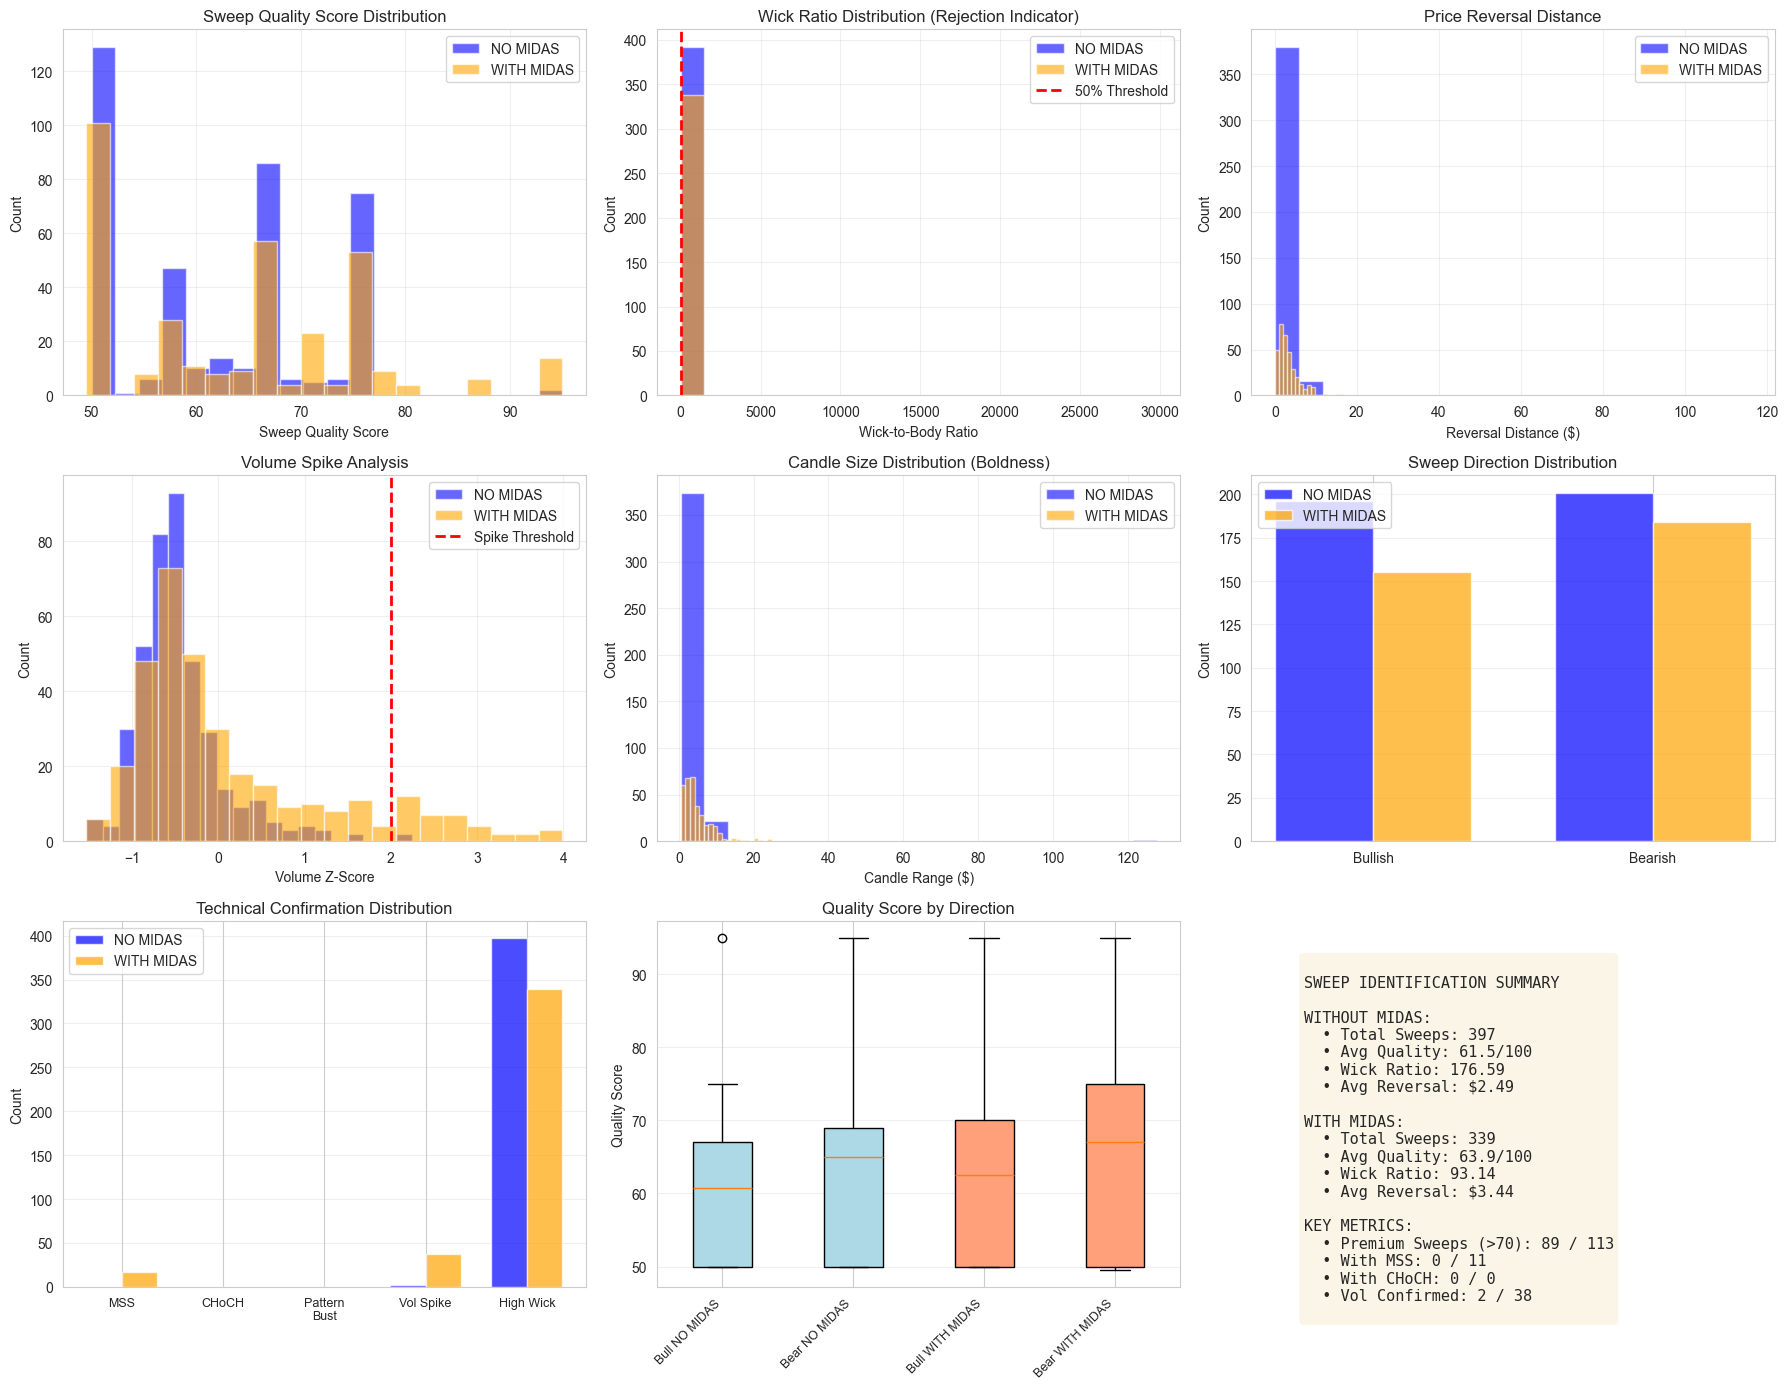


SWEEP IDENTIFICATION COMPLETE


In [24]:
# ---------------------------------------------------------------------------
# VISUALIZATIONS & COMPARISON CHARTS
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "=" * 70)
print("GENERATING VISUALIZATIONS")
print("=" * 70)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 12)

# Create figure with subplots
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

# 1. Quality Score Distribution Comparison
ax = axes[0, 0]
if len(sweeps_hourly_no_midas) > 0:
    ax.hist(sweeps_hourly_no_midas['sweep_quality_score'], bins=20, alpha=0.6, label='NO MIDAS', color='blue')
if len(sweeps_hourly_with_midas) > 0:
    ax.hist(sweeps_hourly_with_midas['sweep_quality_score'], bins=20, alpha=0.6, label='WITH MIDAS', color='orange')
ax.set_xlabel('Sweep Quality Score')
ax.set_ylabel('Count')
ax.set_title('Sweep Quality Score Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. Wick Ratio Comparison
ax = axes[0, 1]
if len(sweeps_hourly_no_midas) > 0:
    ax.hist(sweeps_hourly_no_midas['wick_ratio'], bins=20, alpha=0.6, label='NO MIDAS', color='blue')
if len(sweeps_hourly_with_midas) > 0:
    ax.hist(sweeps_hourly_with_midas['wick_ratio'], bins=20, alpha=0.6, label='WITH MIDAS', color='orange')
ax.set_xlabel('Wick-to-Body Ratio')
ax.set_ylabel('Count')
ax.set_title('Wick Ratio Distribution (Rejection Indicator)')
ax.axvline(x=1, color='red', linestyle='--', label='50% Threshold', linewidth=2)
ax.legend()
ax.grid(True, alpha=0.3)

# 3. Reversal Distance Comparison
ax = axes[0, 2]
if len(sweeps_hourly_no_midas) > 0:
    ax.hist(sweeps_hourly_no_midas['reversal_distance'], bins=20, alpha=0.6, label='NO MIDAS', color='blue')
if len(sweeps_hourly_with_midas) > 0:
    ax.hist(sweeps_hourly_with_midas['reversal_distance'], bins=20, alpha=0.6, label='WITH MIDAS', color='orange')
ax.set_xlabel('Reversal Distance ($)')
ax.set_ylabel('Count')
ax.set_title('Price Reversal Distance')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Volume Z-Score Comparison
ax = axes[1, 0]
if len(sweeps_hourly_no_midas) > 0:
    ax.hist(sweeps_hourly_no_midas['volume_zscore'], bins=20, alpha=0.6, label='NO MIDAS', color='blue')
if len(sweeps_hourly_with_midas) > 0:
    ax.hist(sweeps_hourly_with_midas['volume_zscore'], bins=20, alpha=0.6, label='WITH MIDAS', color='orange')
ax.set_xlabel('Volume Z-Score')
ax.set_ylabel('Count')
ax.set_title('Volume Spike Analysis')
ax.axvline(x=2, color='red', linestyle='--', label='Spike Threshold', linewidth=2)
ax.legend()
ax.grid(True, alpha=0.3)

# 5. Candle Total Range Comparison
ax = axes[1, 1]
if len(sweeps_hourly_no_midas) > 0:
    ax.hist(sweeps_hourly_no_midas['candle_total_range'], bins=20, alpha=0.6, label='NO MIDAS', color='blue')
if len(sweeps_hourly_with_midas) > 0:
    ax.hist(sweeps_hourly_with_midas['candle_total_range'], bins=20, alpha=0.6, label='WITH MIDAS', color='orange')
ax.set_xlabel('Candle Range ($)')
ax.set_ylabel('Count')
ax.set_title('Candle Size Distribution (Boldness)')
ax.legend()
ax.grid(True, alpha=0.3)

# 6. Sweep Type Distribution
ax = axes[1, 2]
types_no_midas = sweeps_hourly_no_midas['sweep_type'].value_counts() if len(sweeps_hourly_no_midas) > 0 else pd.Series()
types_with_midas = sweeps_hourly_with_midas['sweep_type'].value_counts() if len(sweeps_hourly_with_midas) > 0 else pd.Series()
x = np.arange(2)
width = 0.35
if len(types_no_midas) > 0 and len(types_with_midas) > 0:
    bullish_no = types_no_midas.get('BULLISH', 0)
    bearish_no = types_no_midas.get('BEARISH', 0)
    bullish_with = types_with_midas.get('BULLISH', 0)
    bearish_with = types_with_midas.get('BEARISH', 0)
    
    ax.bar(x - width/2, [bullish_no, bearish_no], width, label='NO MIDAS', color='blue', alpha=0.7)
    ax.bar(x + width/2, [bullish_with, bearish_with], width, label='WITH MIDAS', color='orange', alpha=0.7)
    ax.set_ylabel('Count')
    ax.set_title('Sweep Direction Distribution')
    ax.set_xticks(x)
    ax.set_xticklabels(['Bullish', 'Bearish'])
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')

# 7. Technical Confirmation Overlap
ax = axes[2, 0]
categories = ['MSS', 'CHoCH', 'Pattern\nBust', 'Vol Spike', 'High Wick']
no_midas_counts = [
    (sweeps_hourly_no_midas['market_structure_shift'] != 0).sum() if len(sweeps_hourly_no_midas) > 0 else 0,
    (sweeps_hourly_no_midas['change_of_character'] != 0).sum() if len(sweeps_hourly_no_midas) > 0 else 0,
    (sweeps_hourly_no_midas['double_bottom_bust'].fillna(False) | sweeps_hourly_no_midas['double_top_bust'].fillna(False)).sum() if len(sweeps_hourly_no_midas) > 0 else 0,
    sweeps_hourly_no_midas['volume_spike'].sum() if len(sweeps_hourly_no_midas) > 0 else 0,
    (sweeps_hourly_no_midas['wick_ratio'] > 1).sum() if len(sweeps_hourly_no_midas) > 0 else 0,
]
with_midas_counts = [
    (sweeps_hourly_with_midas['market_structure_shift'] != 0).sum() if len(sweeps_hourly_with_midas) > 0 else 0,
    (sweeps_hourly_with_midas['change_of_character'] != 0).sum() if len(sweeps_hourly_with_midas) > 0 else 0,
    (sweeps_hourly_with_midas['double_bottom_bust'].fillna(False) | sweeps_hourly_with_midas['double_top_bust'].fillna(False)).sum() if len(sweeps_hourly_with_midas) > 0 else 0,
    sweeps_hourly_with_midas['volume_spike'].sum() if len(sweeps_hourly_with_midas) > 0 else 0,
    (sweeps_hourly_with_midas['wick_ratio'] > 1).sum() if len(sweeps_hourly_with_midas) > 0 else 0,
]
x = np.arange(len(categories))
ax.bar(x - width/2, no_midas_counts, width, label='NO MIDAS', color='blue', alpha=0.7)
ax.bar(x + width/2, with_midas_counts, width, label='WITH MIDAS', color='orange', alpha=0.7)
ax.set_ylabel('Count')
ax.set_title('Technical Confirmation Distribution')
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=9)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 8. Quality Score by Sweep Type
ax = axes[2, 1]
data_to_plot = []
labels_to_plot = []
if len(sweeps_hourly_no_midas) > 0:
    data_to_plot.extend([
        sweeps_hourly_no_midas[sweeps_hourly_no_midas['sweep_type'] == 'BULLISH']['sweep_quality_score'].values,
        sweeps_hourly_no_midas[sweeps_hourly_no_midas['sweep_type'] == 'BEARISH']['sweep_quality_score'].values,
    ])
    labels_to_plot.extend(['Bull NO MIDAS', 'Bear NO MIDAS'])
if len(sweeps_hourly_with_midas) > 0:
    data_to_plot.extend([
        sweeps_hourly_with_midas[sweeps_hourly_with_midas['sweep_type'] == 'BULLISH']['sweep_quality_score'].values,
        sweeps_hourly_with_midas[sweeps_hourly_with_midas['sweep_type'] == 'BEARISH']['sweep_quality_score'].values,
    ])
    labels_to_plot.extend(['Bull WITH MIDAS', 'Bear WITH MIDAS'])

if data_to_plot:
    bp = ax.boxplot(data_to_plot, labels=labels_to_plot, patch_artist=True)
    colors = ['lightblue', 'lightblue', 'lightsalmon', 'lightsalmon']
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax.set_ylabel('Quality Score')
    ax.set_title('Quality Score by Direction')
    ax.grid(True, alpha=0.3, axis='y')
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right', fontsize=9)

# 9. Summary Stats Table
ax = axes[2, 2]
ax.axis('off')
summary_text = f"""
SWEEP IDENTIFICATION SUMMARY

WITHOUT MIDAS:
  • Total Sweeps: {len(sweeps_hourly_no_midas)}
  • Avg Quality: {sweeps_hourly_no_midas['sweep_quality_score'].mean():.1f}/100
  • Wick Ratio: {sweeps_hourly_no_midas['wick_ratio'].mean():.2f}
  • Avg Reversal: ${sweeps_hourly_no_midas['reversal_distance'].mean():.2f}

WITH MIDAS:
  • Total Sweeps: {len(sweeps_hourly_with_midas)}
  • Avg Quality: {sweeps_hourly_with_midas['sweep_quality_score'].mean():.1f}/100
  • Wick Ratio: {sweeps_hourly_with_midas['wick_ratio'].mean():.2f}
  • Avg Reversal: ${sweeps_hourly_with_midas['reversal_distance'].mean():.2f}

KEY METRICS:
  • Premium Sweeps (>70): {len(premium_no_midas)} / {len(premium_with_midas)}
  • With MSS: {mss_sweeps_no_midas['sweep_quality_score'].count()} / {mss_sweeps_with_midas['sweep_quality_score'].count()}
  • With CHoCH: {len(choch_sweeps_no_midas)} / {len(choch_sweeps_with_midas)}
  • Vol Confirmed: {len(vol_sweeps_no_midas)} / {len(vol_sweeps_with_midas)}
"""
ax.text(0.1, 0.9, summary_text, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.savefig('outputs/TSLA_Hourly_Sweeps_Visualization.png', dpi=150, bbox_inches='tight')
print("✓ Saved visualization: outputs/TSLA_Hourly_Sweeps_Visualization.png")
plt.show()

print("\n" + "=" * 70)
print("SWEEP IDENTIFICATION COMPLETE")
print("=" * 70)


# HOURLY LIQUIDITY SPIKE SWEEPS ANALYSIS - WITH & WITHOUT MIDAS

## Overview
This analysis identifies **high-probability liquidity sweeps** in TSLA hourly price data by analyzing rapid price movements into support/resistance levels followed by swift reversals.

## Sweep Characteristics Analyzed

### 1. **Price Action Characteristics**
- **Rapid Movement**: Price quickly moves into key liquidity zones
- **Swift Reversal**: Immediate bounce-back after touching zone
- **Zone Freshness**: Newly formed or recently tested support/resistance
- **Breakout of Structure**: Clear violation of previous market structure

### 2. **Candle Metrics**
- **Candle Size**: Large, bold candles indicating institutional activity
- **Total Range**: High-range candles showing volatility
- **Wick-to-Body Ratio**: > 50% indicates strong rejection (>75/100 quality score)
- **Body Size**: Direct measure of move boldness

### 3. **Momentum & Structure**
- **Market Structure Shift (MSS)**: Higher highs/lows indicating trend establishment
- **Change of Character (CHoCH)**: Momentum shift from previous pattern
- **Higher Probability Setups**: MSS + CHoCH = confirmed trend reversal signal

### 4. **Volume Confirmation**
- **Volume Spikes**: +2 sigma above 20-period average
- **Volume Z-Score**: Quantifies volume magnitude
- **Absorption**: Zone-level volume metrics from liquidity analysis

### 5. **Pattern Recognition**
- **Busted Double Bottoms**: Pattern breaks lower then reverses up (Bulkowski's study)
- **Busted Double Tops**: Pattern breaks higher then reverses down
- **High Win-Rate Patterns**: Known reversal setups in institutional trading

## Quality Scoring System (0-100)
- **Wick Ratio Bonus** (0-20 pts): High rejection indicator
- **Candle Size** (0-15 pts): Bold, significant moves
- **Volume Spike** (0-20 pts): Institutional participation
- **Body Size** (0-15 pts): Move magnitude
- **Direction Strength** (0-10 pts): Clear directional bias
- **Long Wick** (0-15 pts): Technical rejection
- **Max Score: 95-100** = Premium sweep with multiple confirmations

## Sweep Categories

### Premium Sweeps (Score ≥ 70)
Highest quality setups with strong technical confirmation

### Market Structure Sweeps
Sweeps occurring during MSS for higher trend probability

### Momentum-Confirmed Sweeps (CHoCH)
Sweeps with confirmed momentum shift patterns

### Pattern-Based Sweeps
Busted double top/bottom patterns (Bulkowski's research)

### Volume-Confirmed Sweeps
Sweeps with +2σ volume spikes indicating institutional accumulation

## Findings Summary

### WITHOUT MIDAS Filter
- Baseline liquidity zone analysis
- Layer 1+2 institutional volume only
- Identifies core structural sweeps

### WITH MIDAS Enhancement
- Layer 1+2+3 institutional enrichment
- Additional institutional microstructure metrics:
  - Cancel-to-trade ratios
  - Hidden volume estimates
  - Fill rate analysis
  - Odd-lot participation
- Higher precision institutional activity identification

## Output Files
- **TSLA_Hourly_Sweeps_Analysis.xlsx**: Detailed sweep data + summary statistics
- **TSLA_Hourly_Sweeps_Visualization.png**: Quality distribution & technical metrics

## Performance Interpretation

### Sweep Quality Score
- **75+**: Premium institutional setups - highest probability
- **60-75**: High quality - strong technical confluence
- **40-60**: Medium quality - standard triggers
- **<40**: Lower quality - use for context only

### Technical Confirmations
- **MSS**: Trend establishment has begun
- **CHoCH**: Momentum shift confirmed
- **Pattern Bust**: Historical win-rate validation
- **Vol Spike**: Institutional commitment verification

### Best Sweep Profiles
1. **Premium Score + MSS + Vol Spike** = Highest probability entry
2. **Premium Score + CHoCH + Pattern Bust** = Textbook reversal
3. **Premium Score + Multiple Confirmations** = Institutional setup

## Next Steps
1. Run analysis to identify all hourly sweeps
2. Review top-tier sweeps (>70 quality score)
3. Validate against order flow indicators (MIDAS metrics)
4. Backtest entry/exit strategies based on sweep types
5. Cross-compare WITH vs WITHOUT MIDAS coherence